In [23]:
!pip install arch

In [24]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

# Part 1

Create an AR(1) process with $\phi=0.98$ and simulate observations of length 100, 500, and 1000. For each of the three series fit an AR(1) model and run botht the ADF and KPSS. Remark on whether the model can distinguish stationarity via its confidence intervals and how the ADF and KPSS perform

In [56]:
# Citation, the below is adapted from 'unit_root_testing_demo.ipynb' provided during class
# Simple function that takes one argument of observation length
def simulate_ar1(n):
  PHI = 0.98

  ar_stationary = ArmaProcess(ar=[1, -PHI])
  ar_stationary = ar_stationary.generate_sample(nsample=n+100,
                                                burnin=100,
                                                scale=1.0
  )
  return ar_stationary

In [88]:
# Generate the processes
ar1_100 = simulate_ar1(100)
ar1_500 = simulate_ar1(500)
ar1_1000 = simulate_ar1(1000)

In [89]:
# Define a function to format & print the ADF output (AI-generated)
def adf_test(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries)
    dfoutput = pd.Series(dftest, index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', 'Critical Values', 'Max Lag Sum'])
    print(dfoutput)

# Run the Augmented Dickey-Fuller test
adf_test(ar1_100)
print("\n\n")
adf_test(ar1_500)
print("\n\n")
adf_test(ar1_1000)

Results of Dickey-Fuller Test:
Test Statistic                                                         -1.753532
p-value                                                                 0.403763
#Lags Used                                                                     0
Number of Observations Used                                                  199
Critical Values                {'1%': -3.4636447617687436, '5%': -2.876176117...
Max Lag Sum                                                           501.519009
dtype: object



Results of Dickey-Fuller Test:
Test Statistic                                                         -3.099999
p-value                                                                 0.026553
#Lags Used                                                                     2
Number of Observations Used                                                  597
Critical Values                {'1%': -3.4413510722333087, '5%': -2.866393441...
Max Lag Sum                   

In [87]:
# Define a function to format/print the KPSS output (AI generated)
def kpss_test(timeseries):
    print('Results of KPSS Test:')
    kpsstest = kpss(timeseries)
    kpss_output = pd.Series(kpsstest, index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    print(kpss_output)

# Run the KPSS test
kpss_test(ar1_100)
kpss_test(ar1_500)
kpss_test(ar1_1000)

Results of KPSS Test:
Test Statistic                                                          1.193698
p-value                                                                     0.01
#Lags Used                                                                     9
Number of Observations Used    {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%...
dtype: object
Results of KPSS Test:
Test Statistic                                                          0.245773
p-value                                                                      0.1
#Lags Used                                                                    15
Number of Observations Used    {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%...
dtype: object
Results of KPSS Test:
Test Statistic                                                          0.863259
p-value                                                                     0.01
#Lags Used                                                                    19
Number of Obser

/tmp/ipython-input-215676510.py:4: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/tmp/ipython-input-215676510.py:4: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipython-input-215676510.py:4: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




Ok, so to set the stage for what to look for we know that the AR series is stationary if $\phi$ is less than 1 otherwise the series explodes. Hence, if the confidence interval includes 1 or greater the ADF or KPSS test would have failed to distinguish that this series was stationary.

Now when looking at the Augmented Dickey Fuller test we can see that the p-value is greater than a common $\alpha$ like 0.05 for 100. And at 500, 1000 observations does the p-value clear the $\alpha$ to reject the null hypothesis of non-stationarity. I also wanted to note that depending on the simulation the p-value of observation length 500 will sometimes fail to reject the null hypothesis (succeeds more often than not).

Then, looking at the KPSS test we can see that the p-value of all three observation lengths clear the common threshold of $\alpha=0.05$ with a p-value at or very close to 0.1 even after numerous reruns reject the null hypothesis of non-stationarity.

# Part 2

Download the West Texas Intermediate Crude Oil Prices from https://fred.stlouisfed.org/series/DCOILWTICO and extract the period from January 1, 1990 until January 1, 2020.

In [66]:
# Read csv from the given link
url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=DCOILWTICO&scale=left&cosd=1986-01-02&coed=2025-11-10&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2025-11-16&revision_date=2025-11-16&nd=1986-01-02'
df = pd.read_csv(url)

# Sanity check
print(df)

# Get types of both columns
print(df.dtypes)

      observation_date  DCOILWTICO
0           1986-01-02       25.56
1           1986-01-03       26.00
2           1986-01-06       26.53
3           1986-01-07       25.85
4           1986-01-08       25.87
...                ...         ...
10393       2025-11-04       61.38
10394       2025-11-05       60.40
10395       2025-11-06       60.24
10396       2025-11-07       60.54
10397       2025-11-10       60.94

[10398 rows x 2 columns]
observation_date     object
DCOILWTICO          float64
dtype: object


In [70]:
# Filter the dataframe
df_filtered = df[df['observation_date'] >= '1990-01-01']
df_filtered = df_filtered[df_filtered['observation_date'] <= '2020-01-01']

# Sanity Check
print(df_filtered.head())
print(df_filtered.info())

     observation_date  DCOILWTICO
1042       1990-01-01         NaN
1043       1990-01-02       22.88
1044       1990-01-03       23.81
1045       1990-01-04       23.41
1046       1990-01-05       23.07
<class 'pandas.core.frame.DataFrame'>
Index: 7828 entries, 1042 to 8869
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  7828 non-null   object 
 1   DCOILWTICO        7550 non-null   float64
dtypes: float64(1), object(1)
memory usage: 183.5+ KB
None


In [71]:
# Ensure 'observation_date' is datetime type for plotting
df_filtered['observation_date'] = pd.to_datetime(df_filtered['observation_date'])

# Plot the data using plotly
fig = px.line(df_filtered, x='observation_date', y='DCOILWTICO', title='West Texas Intermediate Crude Oil Prices')
fig.show()

## Part A

Calculate $r_t$ for the data and plot both the ACF and PACF of $r_t$.

In [72]:
# Citation, adapted from 'arch_garch_demo.ipynb' provided during class
# Set 'observation_date' as the index to enable date arithmetic
df_filtered = df_filtered.set_index('observation_date')

df_filtered["log_DCOILWTICO"] = np.log(df_filtered["DCOILWTICO"])
dcoilwt_diff_df = df_filtered.diff().dropna()
dcoilwt_diff_df["log_DCOILWTICO"] = np.log(df_filtered["DCOILWTICO"]).diff().dropna()
dcoilwt_diff_df

,DCOILWTICO,log_DCOILWTICO
observation_date,,
1990-01-03,0.93,0.039842
1990-01-04,-0.40,-0.016942
1990-01-05,-0.34,-0.014630
1990-01-08,-1.43,-0.063990
1990-01-09,0.61,0.027799
...,...,...
2019-12-23,0.08,0.001323
2019-12-24,0.66,0.010848
2019-12-27,0.04,0.000648


In [73]:
fig = px.line(data_frame=dcoilwt_diff_df,
               x=dcoilwt_diff_df.index,
               y="DCOILWTICO",
               title="Change in Daily DCOILWTICO Index",
               labels={"observation_date": "Date",},
               template="seaborn",
               )
fig.update_layout(title_font_size=30,
                  xaxis_tickfont_size=18,
                  yaxis_tickfont_size=18,
                  xaxis_title_font_size=25,
                  yaxis_title_font_size=25,
                  plot_bgcolor='rgba(0,0,0,0)'
                  )
fig.update_yaxes(range=[-20, 20])
fig.update_xaxes(range=[pd.to_datetime("1990-01-01"), dcoilwt_diff_df.index[-1]])
fig.show()

In [74]:
fig = px.line(data_frame=dcoilwt_diff_df,
               x=dcoilwt_diff_df.index,
               y="log_DCOILWTICO",
               title="Change in Daily DCOILWTICO Index (Log Transformed)",
               labels={"observation_date": "Date", "log_DCOILWTICO": "DCOILWTICO (Logarithmic)"},
               template="seaborn",
               )
fig.update_layout(title_font_size=30,
                  xaxis_tickfont_size=18,
                  yaxis_tickfont_size=18,
                  xaxis_title_font_size=25,
                  yaxis_title_font_size=25,
                  plot_bgcolor='rgba(0,0,0,0)'
                  )

fig.update_xaxes(range=[pd.to_datetime("1990-01-01"), dcoilwt_diff_df.index[-1]])
fig.show()

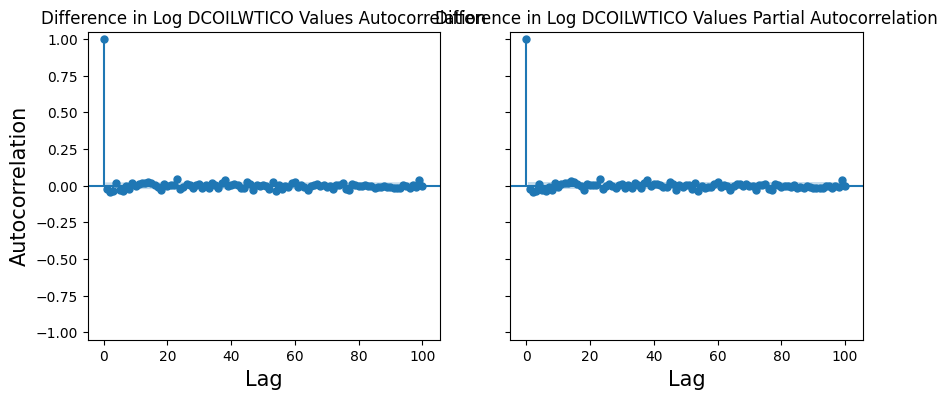

In [75]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)
USE_BARTLETT = True
CONF = 0.05
plot_acf(dcoilwt_diff_df["log_DCOILWTICO"],
         lags=100,
         ax=ax[0],
         bartlett_confint=USE_BARTLETT,
         alpha=CONF,
         )
plot_pacf(dcoilwt_diff_df["log_DCOILWTICO"],
          lags=100,
          ax=ax[1],
          alpha=CONF,
          )

ax[0].set_ylim(-1.05, 1.05)
ax[1].set_ylim(-1.05, 1.05)
ax[0].set_ylabel("Autocorrelation", size=15)
ax[0].set_xlabel("Lag", size=15)
ax[1].set_xlabel("Lag", size=15)
ax[0].set_title("Difference in Log DCOILWTICO Values Autocorrelation")
ax[1].set_title("Difference in Log DCOILWTICO Values Partial Autocorrelation")
fig.show()

## Part B

Plot the ACF and PACF of $r^2_t$.

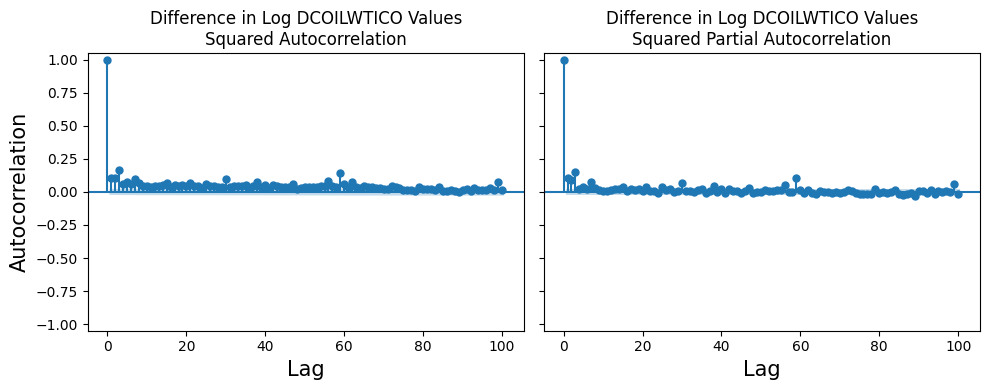

In [76]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)
USE_BARTLETT = True
CONF = 0.05
plot_acf(dcoilwt_diff_df["log_DCOILWTICO"]**2,
         lags=100,
         ax=ax[0],
         bartlett_confint=USE_BARTLETT,
         alpha=CONF,
         )
plot_pacf(dcoilwt_diff_df["log_DCOILWTICO"]**2,
          lags=100,
          ax=ax[1],
          alpha=CONF,
          )

ax[0].set_ylim(-1.05, 1.05)
ax[1].set_ylim(-1.05, 1.05)
ax[0].set_ylabel("Autocorrelation", size=15)
ax[0].set_xlabel("Lag", size=15)
ax[1].set_xlabel("Lag", size=15)
ax[0].set_title("Difference in Log DCOILWTICO Values\nSquared Autocorrelation")
ax[1].set_title("Difference in Log DCOILWTICO Values\nSquared Partial Autocorrelation")
fig.tight_layout()
fig.show()

## Part C

Examine the four plots from above. Do they indicate that an ARCH or GARCH model may be appropriate?

So looking at the lecture slides, I see "A pure ARCH(p) model will theoretically exhibit a decaying ACF and a sudden cut-off in the PACF, whereas a GARCH(p,q) model will exhibit decay in both the ACF and PACF" along with the disclaimer that these are generalizations.

In $r_t$ we can see both ACF and PACF cutoff and in $r^2_t$ we can see what looks like an exponential decay (just zoomed way out). So while visual approximations are not conclusive, a GARCH model seems like a good guess.

## Part D

Fit an ARCH(1), and ARCH(2), and a GARCH(1,1) model to $r_t$.

In [77]:
# create a date to split into testing and training
pred_length = 365
split_date = dcoilwt_diff_df.index[-1] - pd.Timedelta(pred_length, unit="d")
split_date

Timestamp('2018-12-31 00:00:00')

In [78]:
# Fit ARCH(1) model
arch1_model = arch_model(y=100*dcoilwt_diff_df['log_DCOILWTICO'].dropna(), vol='ARCH', p=1, mean="Zero")
arch1_fit = arch1_model.fit(last_obs=split_date)
print("ARCH(1) Model Results:")
print(arch1_fit.summary())

# Fit ARCH(2) model
arch2_model = arch_model(y=100*dcoilwt_diff_df['log_DCOILWTICO'].dropna(), vol='ARCH', p=2, mean="Zero")
arch2_fit = arch2_model.fit(last_obs=split_date)
print("\nARCH(2) Model Results:")
print(arch2_fit.summary())

# Fit GARCH(1,1) model
garch11_model = arch_model(y=100*dcoilwt_diff_df['log_DCOILWTICO'].dropna(), vol='GARCH', p=1, q=1, mean="Constant")
garch11_fit = garch11_model.fit(last_obs=split_date)
print("\nGARCH(1,1) Model Results:")
print(garch11_fit.summary())

Iteration:      1,   Func. Count:      4,   Neg. LLF: 16230.926147566119
Iteration:      2,   Func. Count:      9,   Neg. LLF: 52757769.201389655
Iteration:      3,   Func. Count:     14,   Neg. LLF: 15948.292074252517
Iteration:      4,   Func. Count:     17,   Neg. LLF: 15948.29205121556
Iteration:      5,   Func. Count:     19,   Neg. LLF: 15948.29205121565
Optimization terminated successfully    (Exit mode 0)
            Current function value: 15948.29205121556
            Iterations: 5
            Function evaluations: 19
            Gradient evaluations: 5
ARCH(1) Model Results:
                        Zero Mean - ARCH Model Results                        
Dep. Variable:         log_DCOILWTICO   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -15948.3
Distribution:                  Normal   AIC:                           31900.6
Method:     

## Part E

Rank the three models by BIC. Do the BIC scores agree with part C?

In [54]:
bic_arch1 = arch1_fit.bic
bic_arch2 = arch2_fit.bic
bic_garch11 = garch11_fit.bic

bic_scores = {
    'ARCH(1)': bic_arch1,
    'ARCH(2)': bic_arch2,
    'GARCH(1,1)': bic_garch11
}

sorted_bic = sorted(bic_scores.items(), key=lambda x: x[1])

print("BIC Scores:")
for model, bic in sorted_bic:
    print(f"{model}: {bic:.2f}")

BIC Scores:
GARCH(1,1): 30612.15
ARCH(2): 31436.68
ARCH(1): 31914.31


Lower BIC is better.

Looking at the sorted scores we can see that the GARCH(1,1) model has the lowest BIC score and this does indeed match the visual approximation of the results in Part (c).